<a href="https://colab.research.google.com/github/ShilpaVasista/Exploratory-Data-Analytics/blob/main/Time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Time Series Example: Daily Student Attendance

Imagine you are a teacher tracking the daily attendance in your class over an entire semester. This is a perfect example of a time series!

*   **Timestamps**: Each day of the semester is a specific timestamp.
*   **Observations**: For each timestamp, you record the number of students present in your class. This number is your quantitative observation.
*   **Equally Spaced Intervals**: Attendance is typically recorded once every day, making the intervals between observations regular and equally spaced (ignoring weekends and holidays, which would be gaps in the series).

**Why is this a Time Series?**

1.  **Collection of Observations**: You have a list of numbers (attendance counts) for many different days.
2.  **Sequentially in Time**: The order of these observations matters. Attendance on Monday affects expectations for Tuesday, and you track it in chronological order.

**What can you learn from this Time Series?**

*   **Trend**: Is attendance generally increasing or decreasing over the year? Perhaps it dips around exam periods or link holidays.
*   **Seasonality**: Do you see patterns? For example, is attendance typically lower on Mondays and Fridays? Is it consistently lower in certain months (e.g., during flu season)?
*   **Outliers**: Were there days with unusually low attendance (e.g., a varchasva, or utsav or before Internals)? These would be visible as sharp dips in your time series plot.
*   **Abrupt Changes**: Did a new college policy (e.g., tracking attendance and collecting undertaking forms every week) suddenly cause attendance to jump up or down significantly?

By analyzing this simple daily attendance time series, a teacher can gain valuable insights into class dynamics, identify potential issues, and make data-driven decisions.

# Time Series Analysis (TSA) using Python Libraries

Time series data includes timestamps and is often generated while monitoring an industrial process or tracking any business metrics. An ordered sequence of timestamp values at equally spaced intervals is referred to as a time series. Analysis of such a time series is used in many applications such as sales forecasting, utility studies, budget analysis, economic forecasting, inventory studies, and so on. There are a plethora of methods that can be used to model and forecast time series.

In this chapter, we are going to explore Time Series Analysis (TSA) using Python libraries. Time series data is in the form of a sequence of quantitative observations about a system or process and is made at successive points in time.

In this lesson, we are going to cover the following topics:
- Understanding time series datasets
- TSA with Open Power System Data


## Understanding the time series dataset

The most essential question would be, what do we mean by time series data? Of course, we have heard about it on several occasions. Perhaps we can define it? Essentially, a time series is a collection of observations made sequentially in time. Note that there are two important key phrases here—a collection of observations and sequentially in time. Since it is a series, it has to be a collection of observations, and since it deals with time, it has to deal with it in a sequential fashion.

Let's take an example of time series data:

The following screenshot illustrates solar energy production (measured in Gigawatt Hours (GWh)) for the first six months of 2016. It also shows the consumption of electricity on both a daily and weekly basis.

### Fundamentals of TSA

In order to understand the time series dataset, let's randomly generate a normalized dataset:

In [ ]:
import os
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

zero_mean_series = np.random.normal(loc=0.0, scale=1., size=50)
print(zero_mean_series)


[ 0.31223176 -1.81656516 -0.68886168  1.53299789 -2.20801422 -1.22508366
 -0.92869626 -0.49464636  1.09353147 -1.46284229  0.76216384  0.4346083
  1.0484356  -0.32175127  0.27866988  0.98679086  0.40317481  0.77595504
 -0.34212102 -0.08456373  0.24871091 -0.16867418 -1.84244527  0.0590181
 -0.53981314  0.71566744 -0.08297319  0.11869823 -0.45937099  0.07185299
 -0.54329147  1.32352142  0.13915307 -0.35868418 -1.34089075 -0.17034657
 -1.00696666 -1.23374     1.36625953  1.24400655 -0.34702463 -0.02265636
  0.35301928 -1.05439841 -1.12533964  1.39334687 -0.73530773 -0.18518197
 -0.49178227  0.07361954]


We have used the NumPy library to generate random datasets. The output given here will be different for you.

Next, we are going to use the seaborn library to plot the time series data.

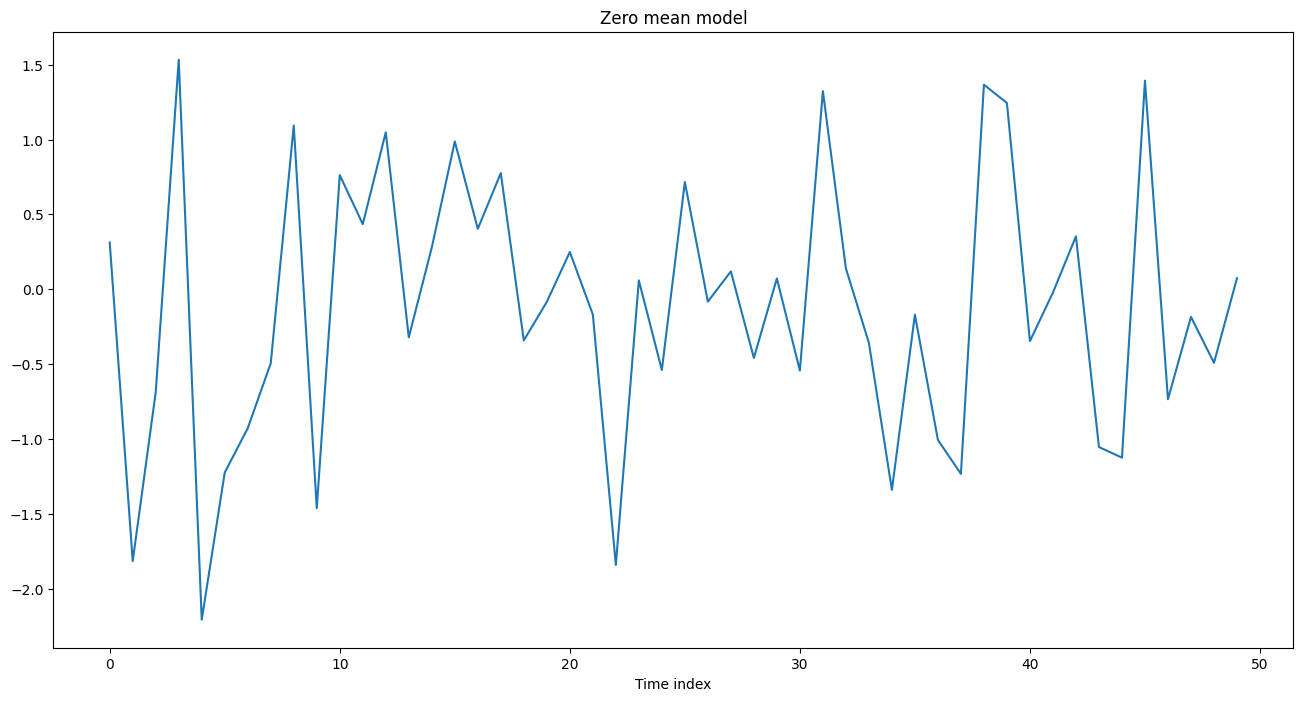

In [ ]:
plt.figure(figsize=(16, 8))
g = sns.lineplot(data=zero_mean_series)
g.set_title('Zero mean model')
g.set_xlabel('Time index')
plt.show()


### Explanation: Zero Mean Model

The `zero_mean_series` is generated using `np.random.normal(loc=0.0, scale=1., size=50)`. This creates 50 random numbers drawn from a normal distribution with a mean (loc) of 0 and a standard deviation (scale) of 1.

When we plot this using `sns.lineplot()`, you see each of these 50 random values plotted against its index (from 0 to 49). The key characteristics are:

*   **Random Fluctuations**: The line jumps up and down unpredictably.
*   **Centred Around Zero**: Most values hover around the 0 mark, reflecting the `loc=0.0` parameter. There's no clear upward or downward trend because the values are purely random and average out to zero over time.

This type of series is often used as a baseline for noise or white noise in time series analysis.

We plotted the time series graph using the `seaborn.lineplot()` function which is a built-in method provided by the seaborn library.

We can perform a cumulative sum over the list and then plot the data using a time series plot. The plot gives more interesting results.

In [ ]:
random_walk = np.cumsum(zero_mean_series)
print(random_walk)


[ 0.31223176 -1.5043334  -2.19319508 -0.66019719 -2.86821142 -4.09329508
 -5.02199134 -5.5166377  -4.42310623 -5.88594852 -5.12378469 -4.68917639
 -3.64074079 -3.96249206 -3.68382218 -2.69703132 -2.29385651 -1.51790146
 -1.86002248 -1.94458622 -1.6958753  -1.86454948 -3.70699476 -3.64797666
 -4.1877898  -3.47212235 -3.55509555 -3.43639732 -3.89576831 -3.82391532
 -4.36720679 -3.04368538 -2.90453231 -3.26321649 -4.60410723 -4.7744538
 -5.78142046 -7.01516046 -5.64890093 -4.40489438 -4.75191902 -4.77457538
 -4.4215561  -5.4759545  -6.60129414 -5.20794727 -5.94325499 -6.12843696
 -6.62021923 -6.54659969]


Note that for any particular value, the next value is the sum of previous values.

Now, if we plot the list using the time series plot, we get an interesting graph that shows the change in values over time:

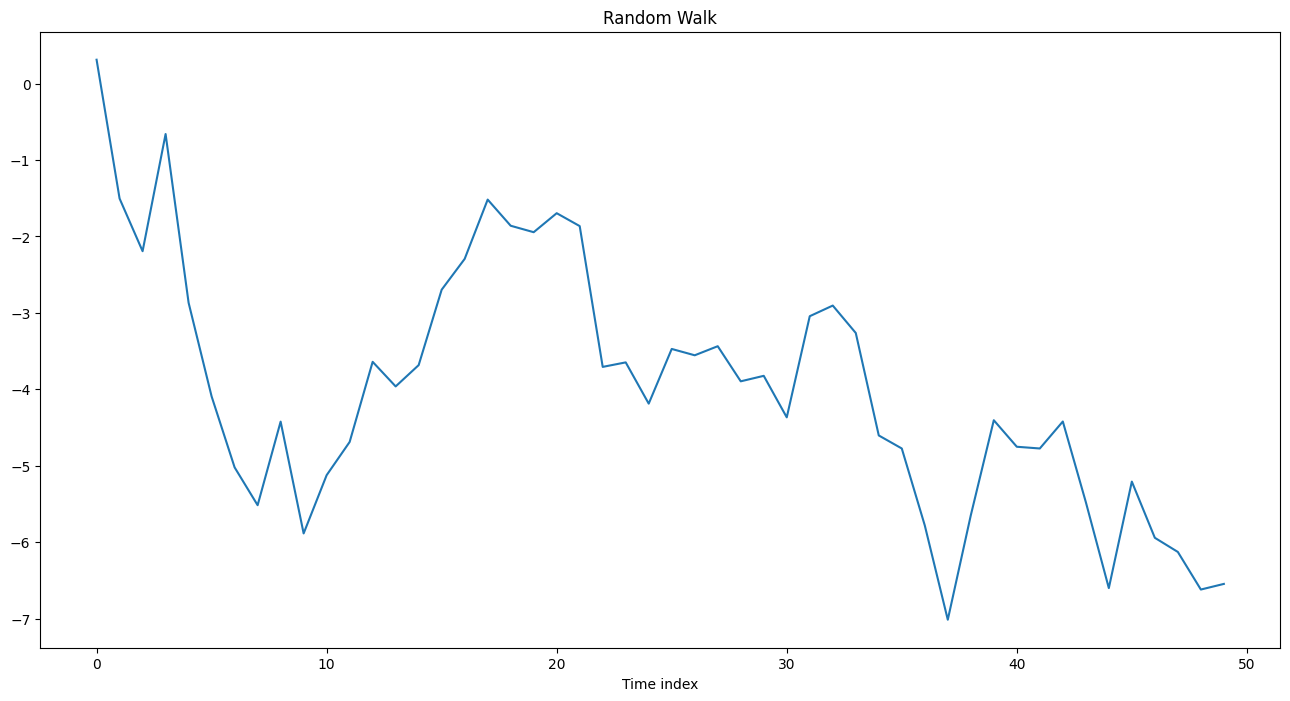

In [ ]:
plt.figure(figsize=(16, 8))
g = sns.lineplot(data=random_walk)
g.set_title('Random Walk')
g.set_xlabel('Time index')
plt.show()


### Explanation: Random Walk

The `random_walk` series is created by taking the **cumulative sum** of the `zero_mean_series` using `np.cumsum()`. This means each point in the `random_walk` is the sum of all previous values from the `zero_mean_series` up to that point.

When plotted, the random walk exhibits a very different behavior from the zero-mean series:

*   **Accumulated Drift**: Instead of fluctuating around zero, the series tends to drift away from its starting point. Even though the individual steps (from `zero_mean_series`) average to zero, their accumulation leads to a path that can wander far from the origin.
*   **No Fixed Mean or Variance**: Unlike the `zero_mean_series`, a random walk does not revert to a mean, and its variance increases over time. This makes it a non-stationary process, which is a crucial concept in time series analysis.

Many real-world phenomena, such as stock prices or exchange rates, are often modeled as random walks because their current value is a sum of past random changes.

Note the graph shown in the preceding diagram. It shows the change of values over time. Great – so far, we have generated different time series data and plotted it using the `seaborn.lineplot()` method.

### Univariate time series

When we capture a sequence of observations for the same variable over a particular duration of time, the series is referred to as univariate time series. In general, in a univariate time series, the observations are taken over regular time periods, such as the change in temperature over time throughout a day.

### Characteristics of time series data

When working with time series data, there are several unique characteristics that can be observed. In general, time series tend to exhibit the following characteristics:

*   **Trend**: It is essential to see if there is any trend. Observing a trend means that the average measurement values seem either to decrease or increase over time.
*   **Outliers**: Time series data may contain a notable amount of outliers. These outliers can be noted when plotted on a graph.
*   **Seasonality**: Some data in time series tends to repeat over a certain interval in some patterns. We refer to such repeating patterns as seasonality.
*   **Abrupt changes**: Sometimes, there is an uneven change in time series data. We refer to such uneven changes as abrupt changes. Observing abrupt changes in time series is essential as it reveals essential underlying phenomena.
*   **Constant variance**: Some series tend to follow constant variance over time. Hence, it is essential to look at the time series data and see whether or not the data exhibits constant variance over time.

The characteristics listed previously help us to make better analyses when it comes to TSA. Now that we know what to see and expect in time series data, it would be useful to see some real examples in action. Next, let's import a real database and perform various TSA methods on it.

## TSA with Open Power System Data

In this section, we are going to use Open Power System Data to understand TSA. We'll look at the time series data structures, time-based indexing, and several ways to visualize time series data.

We will start by importing the dataset.

In [ ]:
import pandas as pd

# load time series dataset
df_power = pd.read_csv("https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv")

print(df_power.columns)


Index(['Date', 'Consumption', 'Wind', 'Solar', 'Wind+Solar'], dtype='object')


The columns of the dataframe are described here:

*   **Date**: The date is in the format yyyy-mm-dd.
*   **Consumption**: This indicates electricity consumption in GWh.
*   **Solar**: This indicates solar power production in GWh.
*   **Wind**: This indicates wind power production in GWh.
*   **Wind+Solar**: This represents the sum of solar and wind power production in GWh.

Note the date column, which contains the time series dataset. We can use this dataset to discover how electricity consumption and production varies over time in Germany.

### Data cleaning

Let's now clean our dataset for outliers:

1.  We can start by checking the shape of the dataset:

In [ ]:
print(df_power.shape)


(4383, 5)


The dataframe contains 4,383 rows and 5 columns.

2.  We can also check a few entries inside the dataframe. Let's examine the last 10 entries:

In [ ]:
display(df_power.tail(10))


,Date,Consumption,Wind,Solar,Wind+Solar
4373,2017-12-22,1423.23782,228.773,10.065,238.838
4374,2017-12-23,1272.17085,748.074,8.450,756.524
4375,2017-12-24,1141.75730,812.422,9.949,822.371
4376,2017-12-25,1111.28338,587.810,15.765,603.575
4377,2017-12-26,1130.11683,717.453,30.923,748.376
4378,2017-12-27,1263.94091,394.507,16.530,411.037
4379,2017-12-28,1299.86398,506.424,14.162,520.586
4380,2017-12-29,1295.08753,584.277,29.854,614.131
4381,2017-12-30,1215.44897,721.247,7.467,728.714
4382,2017-12-31,1107.11488,721.176,19.980,741.156


3.  Next, let's review the data types of each column in our `df_power` dataframe:

In [ ]:
print(df_power.dtypes)


Date            object
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64
dtype: object


4.  Note that the `Date` column has a data type of `object`. This is not correct for time series analysis. So, the next step is to correct the `Date` column by converting it to datetime format:

In [ ]:
#convert object to datetime format
df_power['Date'] = pd.to_datetime(df_power['Date'])


5.  It should convert the `Date` column to Datetime format. We can verify this again:

In [ ]:
print(df_power.dtypes)


Date           datetime64[ns]
Consumption           float64
Wind                  float64
Solar                 float64
Wind+Solar            float64
dtype: object


Note that the `Date` column has been changed into the correct data type (`datetime64[ns]`).

6.  Let's next change the index of our dataframe to the `Date` column:

In [ ]:
df_power = df_power.set_index('Date')
display(df_power.tail(3))


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2017-12-29,1295.08753,584.277,29.854,614.131
2017-12-30,1215.44897,721.247,7.467,728.714
2017-12-31,1107.11488,721.176,19.980,741.156


Note from the preceding screenshot that the `Date` column has been set as `DatetimeIndex`.

7.  We can simply verify this by using the code snippet given here:

In [ ]:
print(df_power.index)


DatetimeIndex(['2006-01-01', '2006-01-02', '2006-01-03', '2006-01-04',
               '2006-01-05', '2006-01-06', '2006-01-07', '2006-01-08',
               '2006-01-09', '2006-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[ns]', name='Date', length=4383, freq=None)


8.  Since our index is the `DatetimeIndex` object, now we can use it to analyze the dataframe. Let's add more columns to our dataframe to make our lives easier. Let's add Year, Month, and Weekday Name:

In [ ]:
# Add columns with year, month, and weekday name
df_power['Year'] = df_power.index.year
df_power['Month'] = df_power.index.month
df_power['Weekday Name'] = df_power.index.day_name() # Use day_name() for full weekday names


9.  Let's display five random rows from the dataframe:

In [ ]:
# Display a random sampling of 5 rows
display(df_power.sample(5, random_state=0))


,Consumption,Wind,Solar,Wind+Solar,Year,Month,Weekday Name
Date,,,,,,,
2008-08-23,1152.011,NaN,NaN,NaN,2008,8,Saturday
2013-08-08,1291.984,79.666,93.371,173.037,2013,8,Thursday
2009-08-27,1281.057,NaN,NaN,NaN,2009,8,Thursday
2015-10-02,1391.050,81.229,160.641,241.870,2015,10,Friday
2009-06-02,1201.522,NaN,NaN,NaN,2009,6,Tuesday


Note that we added three more columns—Year, Month, and Weekday Name. Adding these columns helps to make the analysis of data easier.

### Time-based indexing

Time-based indexing is a very powerful method of the pandas library when it comes to time series data. Having time-based indexing allows using a formatted string to select data. See the following code, for example:

In [ ]:
display(df_power.loc['2015-10-02'])


,2015-10-02
Consumption,1391.05
Wind,81.229
Solar,160.641
Wind+Solar,241.87
Year,2015
Month,10
Weekday Name,Friday


Note that we used the pandas dataframe `loc` accessor. In the preceding example, we used a date as a string to select a row. We can use all sorts of techniques to access rows just as we can do with a normal dataframe index.

### Visualizing time series

Let's visualize the time series dataset. We will continue using the same `df_power` dataframe:

1.  The first step is to import the seaborn and matplotlib libraries and set some plotting parameters:

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(rc={'figure.figsize':(11, 4)})
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 150


2.  Next, let's generate a line plot of the full time series of Germany's daily electricity consumption:

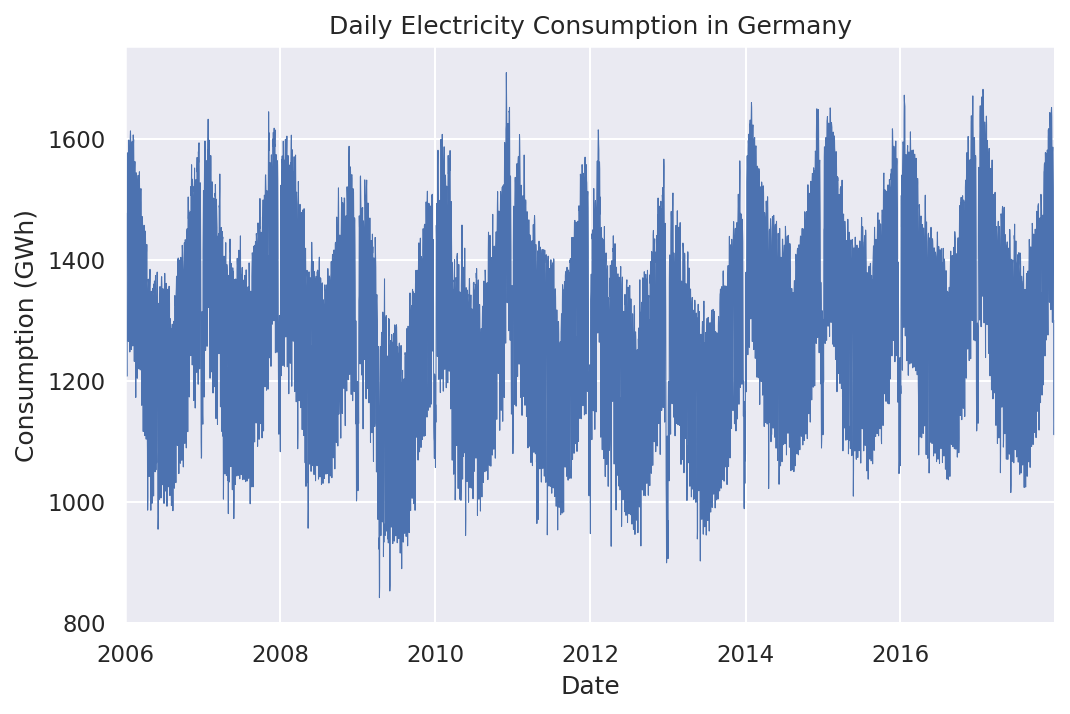

In [ ]:
df_power['Consumption'].plot(linewidth=0.5)
plt.title('Daily Electricity Consumption in Germany')
plt.xlabel('Date')
plt.ylabel('Consumption (GWh)')
plt.show()


As depicted in the preceding screenshot, the y-axis shows the electricity consumption and the x-axis shows the year. However, there are too many datasets to cover all the years.

3.  Let's use the dots to plot the data for all the other columns:

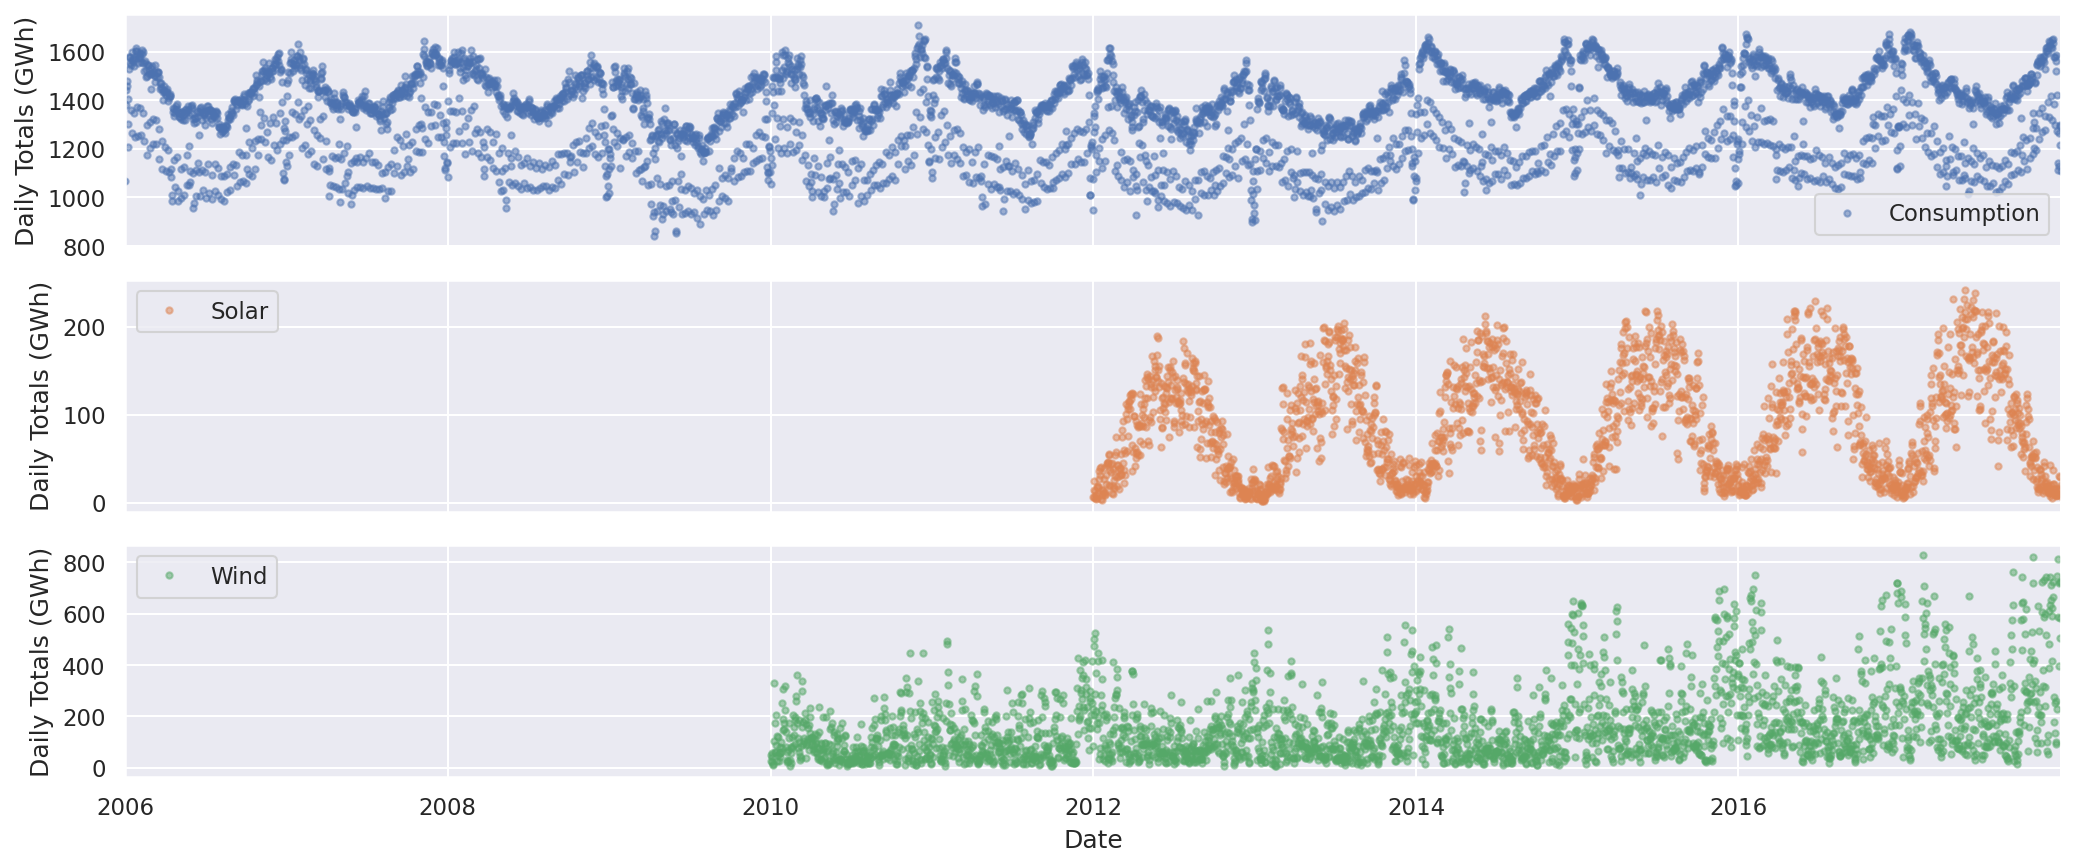

In [ ]:
cols_to_plot = ['Consumption', 'Solar', 'Wind']
axes = df_power[cols_to_plot].plot(marker='.', alpha=0.5, linestyle='None',figsize=(14, 6), subplots=True)
for ax in axes:
    ax.set_ylabel('Daily Totals (GWh)')
plt.tight_layout()
plt.show()


The output shows that electricity consumption can be broken down into two distinct patterns:

*   One cluster roughly from 1,400 GWh and above
*   Another cluster roughly below 1,400 GWh

Moreover, solar production is higher in summer and lower in winter. Over the years, there seems to have been a strong increasing trend in the output of wind power.

4.  We can further investigate a single year to have a closer look.

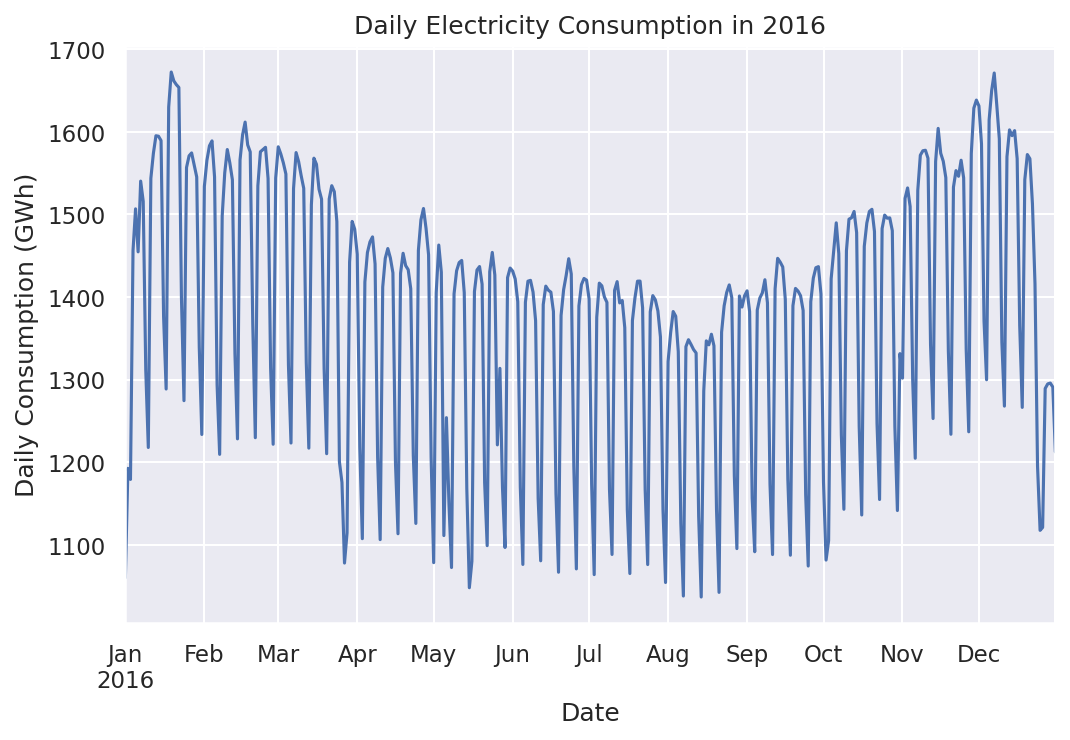

In [ ]:
ax = df_power.loc['2016', 'Consumption'].plot()
ax.set_ylabel('Daily Consumption (GWh)');
plt.title('Daily Electricity Consumption in 2016')
plt.xlabel('Date')
plt.show()


From the preceding screenshot, we can see clearly the consumption of electricity for 2016. The graph shows a drastic decrease in the consumption of electricity at the end of the year (December) and during August. We can look for further details in any particular month. Let's examine the month of December 2016:

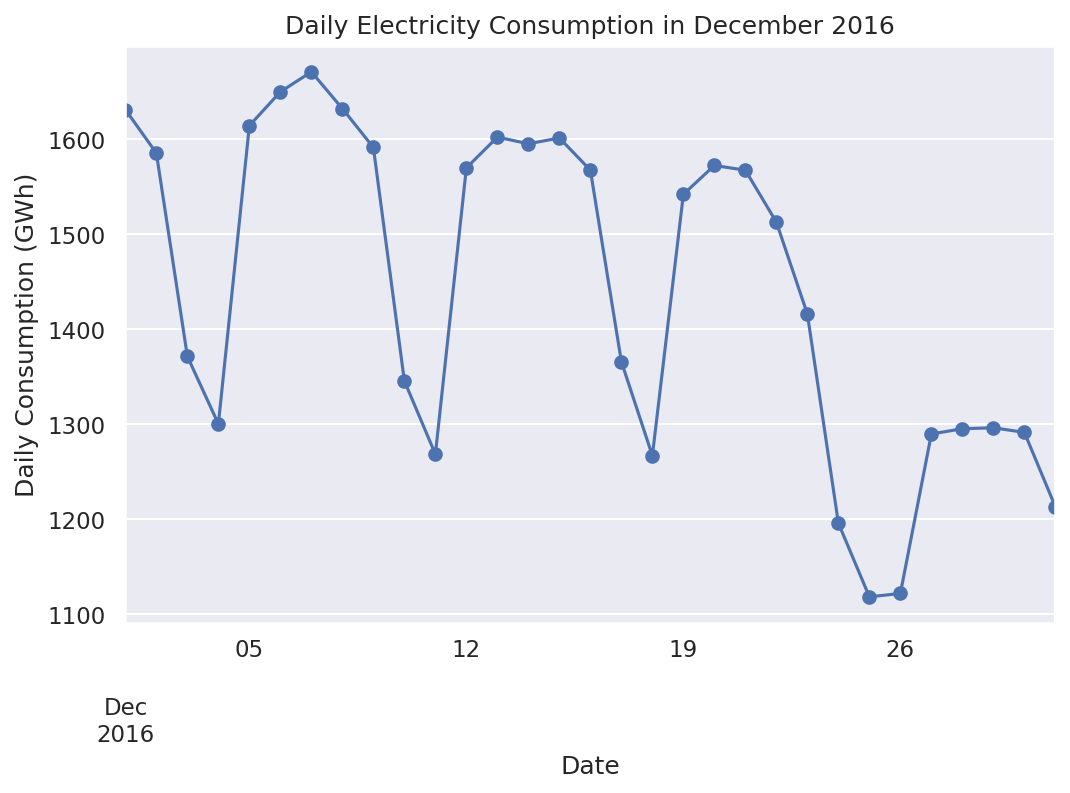

In [ ]:
ax = df_power.loc['2016-12', 'Consumption'].plot(marker='o', linestyle='-')
ax.set_ylabel('Daily Consumption (GWh)');
plt.title('Daily Electricity Consumption in December 2016')
plt.xlabel('Date')
plt.show()


As shown in the preceding graph, electricity consumption is higher on weekdays and lowest at the weekends. We can see the consumption for each day of the month. We can zoom in further to see how consumption plays out in the last week of December.

In order to indicate a particular week of December, we can supply a specific date range as shown here:

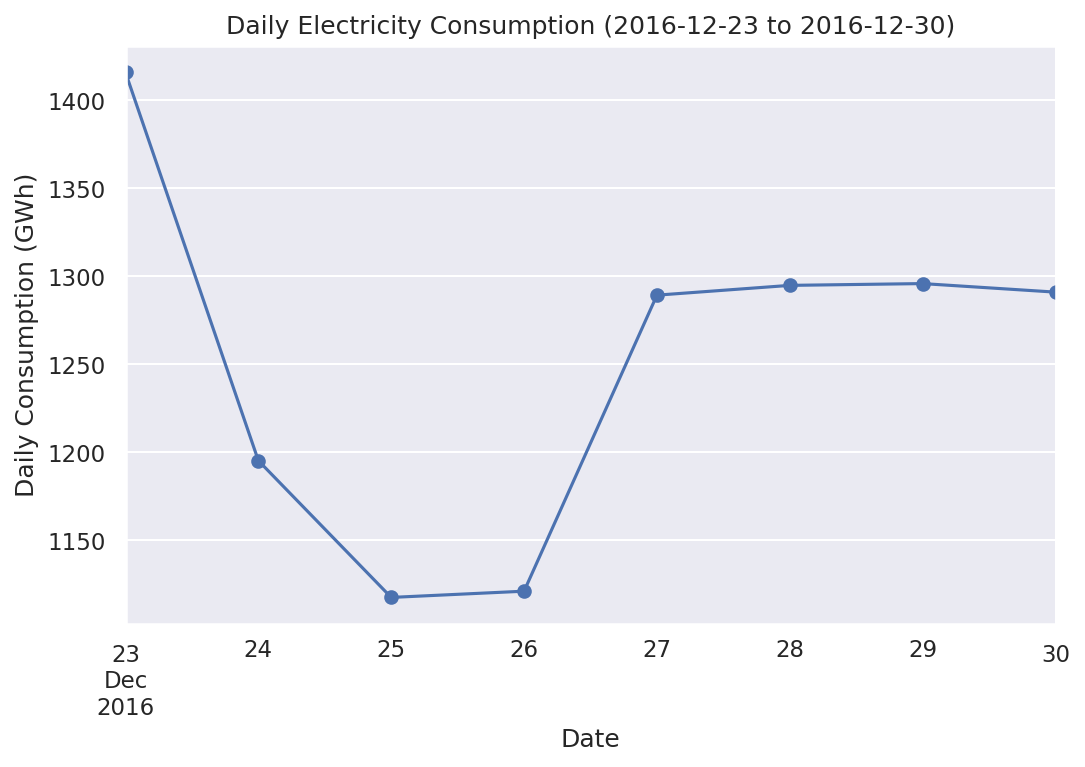

In [ ]:
ax = df_power.loc['2016-12-23':'2016-12-30',
'Consumption'].plot(marker='o', linestyle='-')
ax.set_ylabel('Daily Consumption (GWh)');
plt.title('Daily Electricity Consumption (2016-12-23 to 2016-12-30)')
plt.xlabel('Date')
plt.show()


As illustrated in the preceding screenshot, electricity consumption was lowest on the day of Christmas, probably because people were busy partying. After Christmas, the consumption increased.

### Grouping time series data

We can group the data by different time periods and present them in box plots:

1.  We can first group the data by months and then use the box plots to visualize the data:

/tmp/ipykernel_6187/695974692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_power, x='Month', y=name, ax=ax, palette='viridis') # Added palette
/tmp/ipykernel_6187/695974692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_power, x='Month', y=name, ax=ax, palette='viridis') # Added palette
/tmp/ipykernel_6187/695974692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_power, x='Month', y=name, ax=ax, palette='viridis') # Added palette


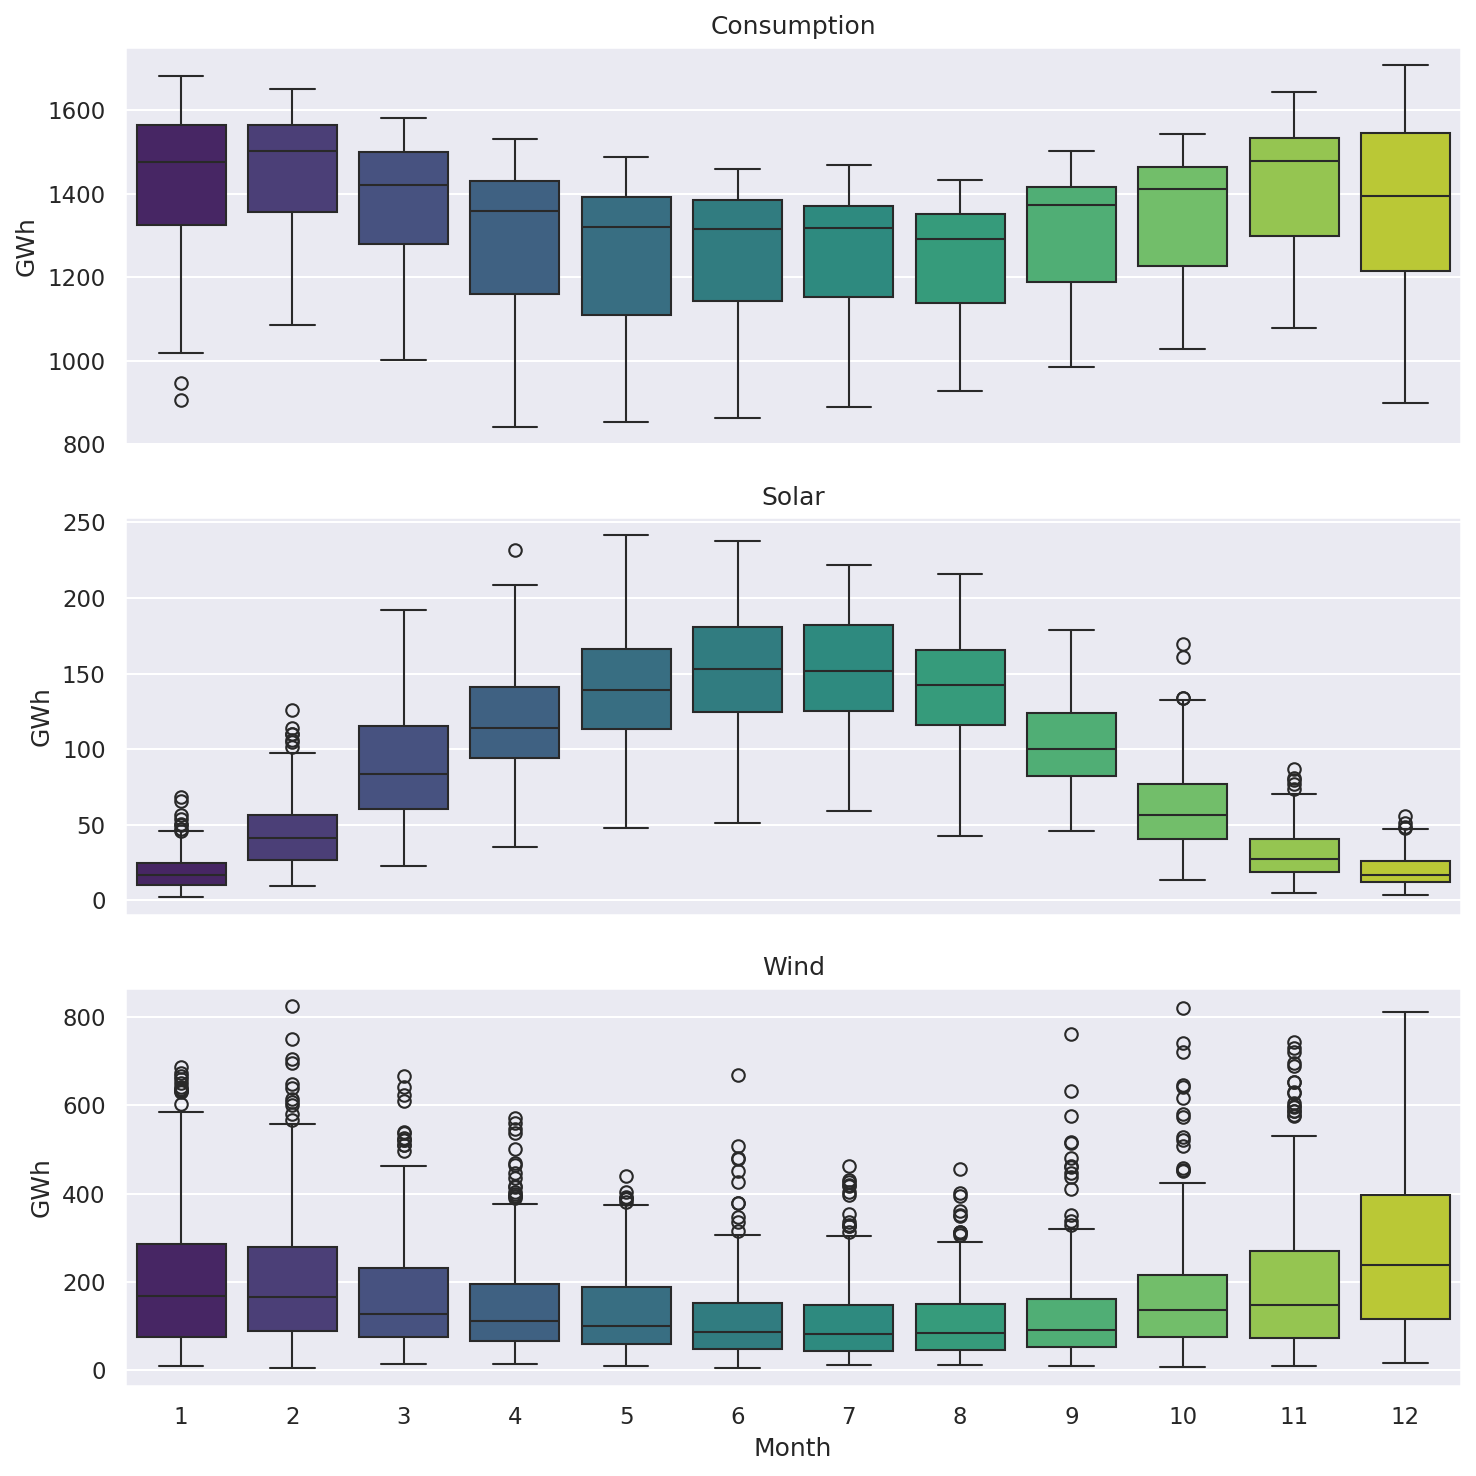

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True) # Adjusted figsize
for name, ax in zip(['Consumption', 'Solar', 'Wind'], axes):
    sns.boxplot(data=df_power, x='Month', y=name, ax=ax, palette='viridis') # Added palette
    ax.set_ylabel('GWh')
    ax.set_title(name)
    if ax != axes[-1]:
        ax.set_xlabel('')
plt.tight_layout()
plt.show()


The preceding plot illustrates that electricity consumption is generally higher in the winter and lower in the summer. Wind production is higher during the summer. Moreover, there are many outliers associated with electricity consumption, wind production, and solar production.

2.  Next, we can group the consumption of electricity by the day of the week, and present it in a box plot:

/tmp/ipykernel_6187/715181273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_power, x='Weekday Name', y='Consumption', palette='coolwarm'); # Added palette


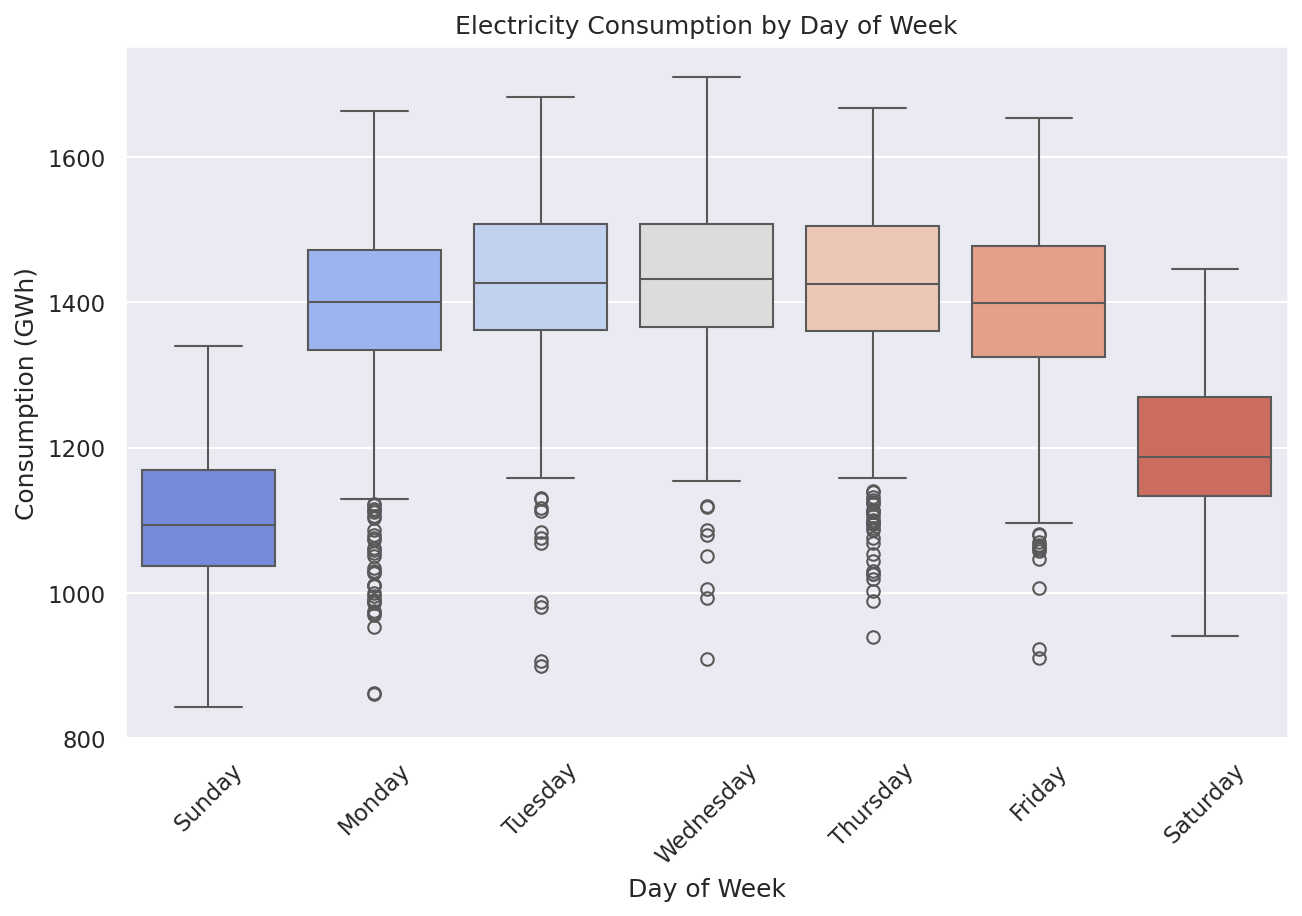

In [ ]:
plt.figure(figsize=(10, 6)) # Added figsize
sns.boxplot(data=df_power, x='Weekday Name', y='Consumption', palette='coolwarm'); # Added palette
plt.title('Electricity Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Consumption (GWh)')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.show()


The preceding screenshot shows that electricity consumption is higher on weekdays than on weekends. Interestingly, there are more outliers on the weekdays.

### Resampling time series data

It is often required to resample the dataset at lower or higher frequencies. This resampling is done based on aggregation or grouping operations. For example, we can resample the data based on the weekly mean time series as follows:

1.  We can use the code given here to resample our data:

In [ ]:
columns = ['Consumption', 'Wind', 'Solar', 'Wind+Solar']
power_weekly_mean = df_power[columns].resample('W').mean()
display(power_weekly_mean.head())


,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2006-01-01,1069.184000,NaN,NaN,NaN
2006-01-08,1381.300143,NaN,NaN,NaN
2006-01-15,1486.730286,NaN,NaN,NaN
2006-01-22,1490.031143,NaN,NaN,NaN
2006-01-29,1514.176857,NaN,NaN,NaN


As shown in the preceding screenshot, the first row includes the average of all the data for that week. We can plot the daily and weekly time series to compare the dataset over a specific period.

2.  Let's see the last six months of 2016. Let's start by initializing the variable:

In [ ]:
start, end = '2016-01', '2016-06'


3.  Next, let's plot the graph comparing daily and weekly mean solar production:

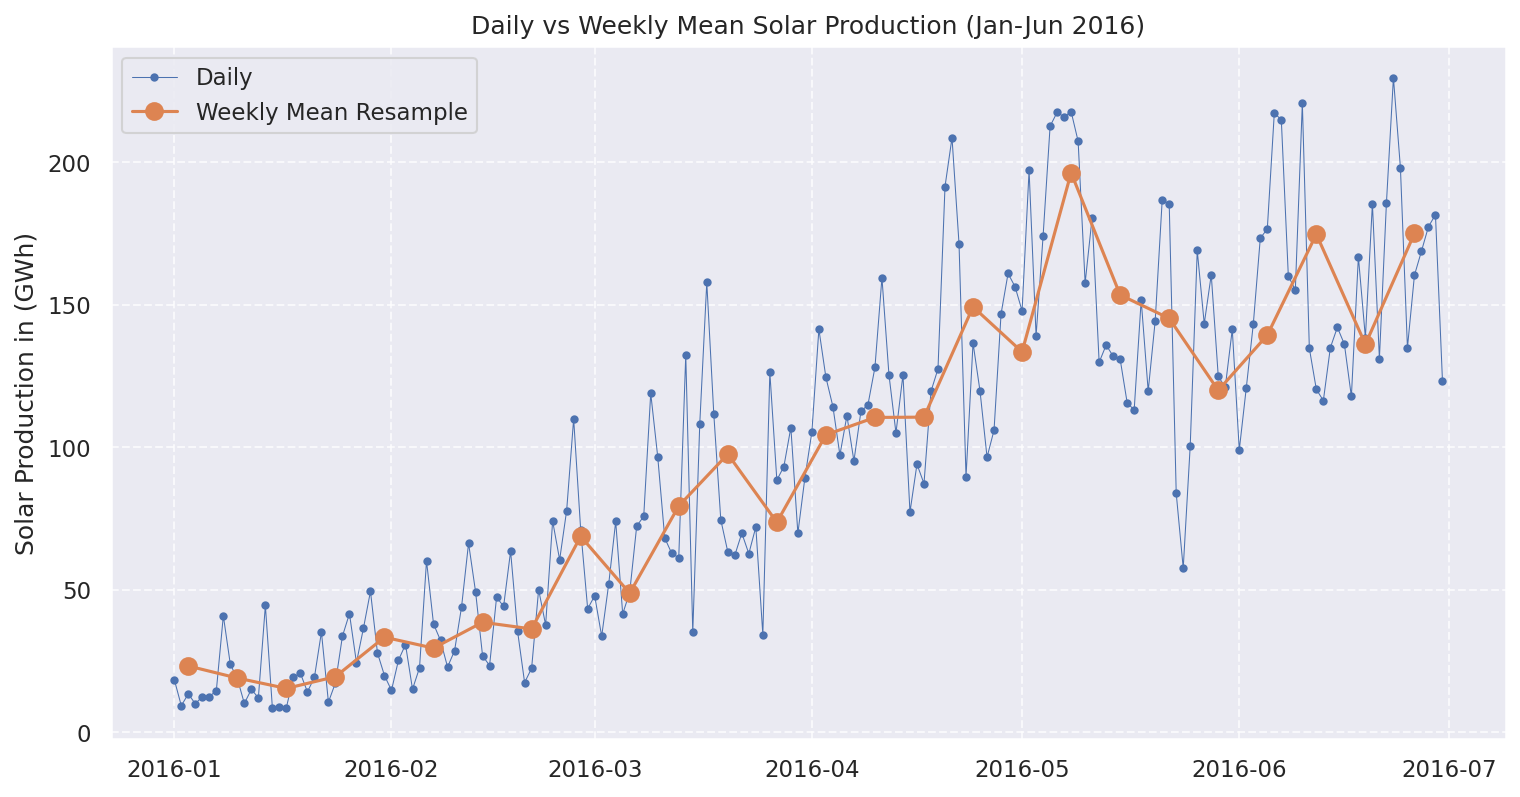

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_power.loc[start:end, 'Solar'],
        marker='.', linestyle='-', linewidth=0.5, label='Daily')
ax.plot(power_weekly_mean.loc[start:end, 'Solar'],
        marker='o', markersize=8, linestyle='-', label='Weekly Mean Resample')
ax.set_ylabel('Solar Production in (GWh)')
ax.set_title('Daily vs Weekly Mean Solar Production (Jan-Jun 2016)')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


The preceding screenshot shows that the weekly mean time series is increasing over time and is much smoother than the daily time series.

## Summary

In this chapter, we have discussed how to import, clean, analyze, and visualize time series datasets using the pandas library. Moreover, we visualized a time series dataset using the matplotlib and seaborn libraries. Finally, we used Python to load and examine the Open Power System Data dataset and performed several techniques associated with TSA.

In the next chapter, we are going to learn about different methods for model development using classical machine learning techniques and three different types of machine learning, namely, supervised learning, unsupervised machine learning, and reinforcement learning.